In [0]:
import math
import matplotlib.pyplot as plt
from scipy.optimize import brentq  # or fsolve/newton if you prefer


In [0]:
def lmtd(T_hot_in, T_hot_out, T_cold_in, T_cold_out):
    dT1 = T_hot_in - T_cold_out
    dT2 = T_hot_out - T_cold_in
    if abs(dT1 - dT2) < 1e-9:
        return dT1
    return (dT1 - dT2) / math.log(dT1 / dT2)

def Tc_out_steady_state(Tb, Tc_in, U, A, m_dot_c, cp_c):
    def residual(Tc_out):
        DeltaT_lm = lmtd(T_hot_in=Tb, T_hot_out=Tb,
                         T_cold_in=Tc_in, T_cold_out=Tc_out)
        Q_UA = U * A * DeltaT_lm
        Q_mcp = m_dot_c * cp_c * (Tc_out - Tc_in)
        return Q_mcp - Q_UA

    Tc_low = Tc_in
    Tc_high = Tb - 1e-6
    return brentq(residual, Tc_low, Tc_high)

# Fixed conditions
Tb = 19.0 + 273.15      # K
Tc_in = 15.0 + 273.15    # K
A = 1.76                 # m^2
cp_c = 4180.0           # J/(kg K)

# Ranges to test
U_values = [285, 570, 850]      # W/(m^2 K)
m_dot_values = [0.1, 0.2, 0.3, 0.5, 1, 2, 4]       # kg/s

results = []  # store (U, m_dot, Tc_out, Q)

for U in U_values:
    for m_dot_c in m_dot_values:
        Tc_out = Tc_out_steady_state(Tb, Tc_in, U, A, m_dot_c, cp_c)
        Q = m_dot_c * cp_c * (Tc_out - Tc_in)  # W
        results.append((U, m_dot_c, Tc_out, Q))
        #print(f"U = {U:4.0f} W/m2K, m_dot = {m_dot_c:4.2f} kg/s  -> "
        #      f"Tc_out = {Tc_out - 273.15:6.2f} °C,  Q = {Q:8.1f} W")
# Sort results by U (ascending), then m_dot (ascending), then Tc_out (ascending)
results_sorted = sorted(results,
    key=lambda x: (x[0], x[1], x[2])  # x[0]=U, x[1]=m_dot, x[2]=Tc_out, x[3]=Q
)


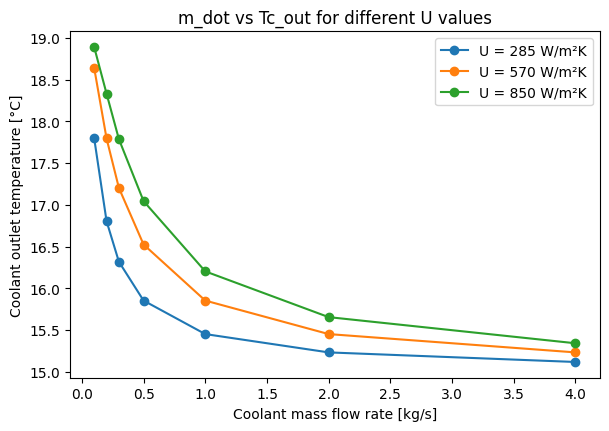

In [0]:

# Collect unique U values
U_values_unique = sorted(set(r[0] for r in results_sorted))

plt.figure(figsize=(6,4))

for U in U_values_unique:
    # filter results for this U
    m_list = []
    Tc_out_list = []
    for UU, m_dot_c, Tc_out, Q in results_sorted:
        if UU == U:
            m_list.append(m_dot_c)
            Tc_out_list.append(Tc_out - 273.15)  # convert to °C if needed

    # plot m vs Tc_out for this U
    plt.plot(m_list, Tc_out_list, marker='o', label=f'U = {U} W/m²K')
plt.tight_layout()
plt.xlabel('Coolant mass flow rate [kg/s]')
plt.ylabel('Coolant outlet temperature [°C]')
plt.title('m_dot vs Tc_out for different U values')
plt.legend()
plt.grid(False)
plt.show()


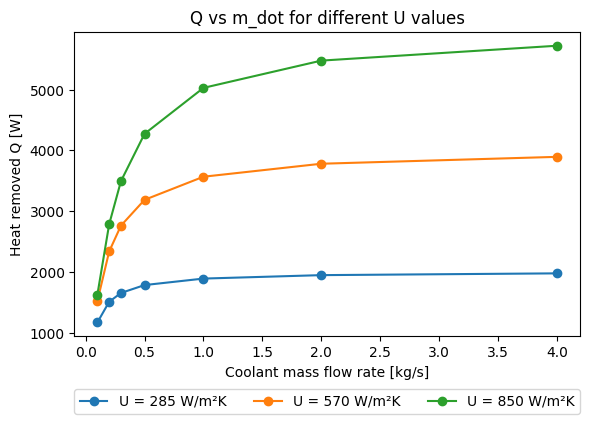

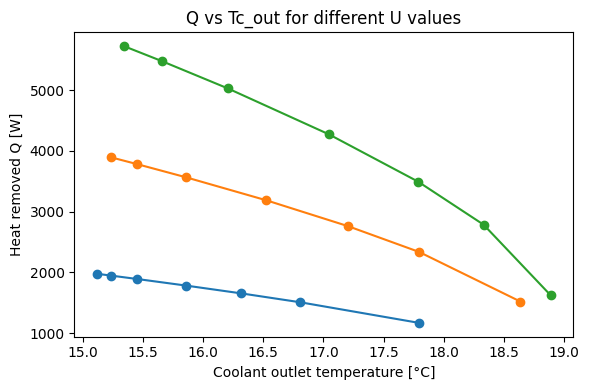

In [0]:
# --- 1) Q vs m_dot for different U ---
plt.figure(figsize=(6,4))
for U in U_values_unique:
    m_list = []
    Q_list = []
    for UU, m_dot_c, Tc_out, Q in results_sorted:
        if UU == U:
            m_list.append(m_dot_c)
            Q_list.append(Q)  # W
    plt.plot(m_list, Q_list, marker='o', label=f'U = {U} W/m²K')

plt.xlabel('Coolant mass flow rate [kg/s]')
plt.ylabel('Heat removed Q [W]')
plt.title('Q vs m_dot for different U values')
plt.grid(False)
plt.tight_layout()
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=3
)
plt.show()

# --- 2) Q vs Tc_out for different U ---
plt.figure(figsize=(6,4))
for U in U_values_unique:
    Tc_out_list = []
    Q_list = []
    for UU, m_dot_c, Tc_out, Q in results_sorted:
        if UU == U:
            Tc_out_list.append(Tc_out - 273.15)  # °C
            Q_list.append(Q)
    plt.plot(Tc_out_list, Q_list, marker='o', label=f'U = {U} W/m²K')

plt.xlabel('Coolant outlet temperature [°C]')
plt.ylabel('Heat removed Q [W]')
plt.title('Q vs Tc_out for different U values')
plt.grid(False)
plt.tight_layout()
plt.show()

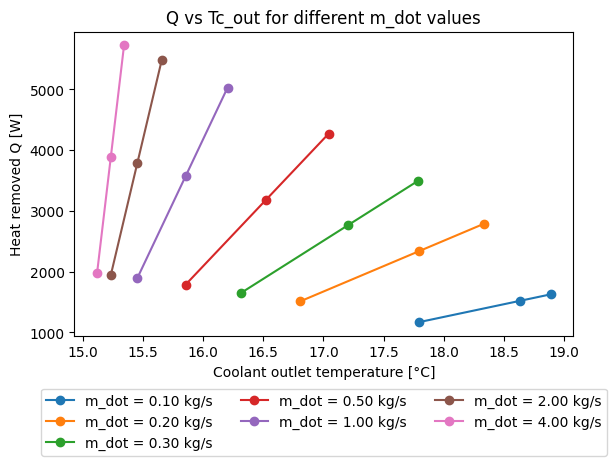

In [0]:
results_sorted = sorted(results, key=lambda x: (x[1], x[0], x[2]))  # sort by m, then U
m_values_unique = sorted(set(r[1] for r in results_sorted))

plt.figure(figsize=(6,4))

for m_dot_c in m_values_unique:
    Tc_out_list = []
    Q_list = []
    for U, m_val, Tc_out, Q in results_sorted:
        if m_val == m_dot_c:
            Tc_out_list.append(Tc_out - 273.15)  # °C
            Q_list.append(Q)                     # W
    plt.plot(Tc_out_list, Q_list, marker='o', label=f'm_dot = {m_dot_c:.2f} kg/s')

plt.xlabel('Coolant outlet temperature [°C]')
plt.ylabel('Heat removed Q [W]')
plt.title('Q vs Tc_out for different m_dot values')
plt.grid(False)
plt.tight_layout()
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=3
)
plt.show()
